<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/ch1_sinusoidworld/Explaining_the_DFT_a_music_perspective_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform (Part 3)

## Dealing with time and phase
## George Tzanetakis - Department of Computer Science, University of Victoria

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.

In Part 1 we looked at how just by combining sinusoid signals of different frequencies and using amplitude envelopes to shape their time evolution we can create complex sounds, melodies and even some chip tune music. Our main focus is going to be the inverse problem. Given a complex sound or a melody or a a chip tune determine all the necessary parameters such as frequencies, amplitudes, duration that would be needed to reconstruct the singal out of sinusoids.

In Part 2 we looked at the problem of amplitude estimation first by looking at peak and RMS amplitude estimation and then moving into using correlation/dot product amplitude estimation which was shown to be extremely robust and accurate in the presense of interfering sounds but has the additional requirement of knowing the frequency you are looking for to create a "probe/basis" signal with unit amplitude and frequency equal to the frequency we are looking for. In addition the probe and the burried in interference signal for which we wouldl like to estimate the amplitude must be phase aligned.

In Part 3 we look into how we can extend our amplitude estimation approach to deal with changes in amplitude over time. In addition we look into how we can deal with the problem of phase alignment. By the end we will have looked at the fundamental building block of the Discrete Fourier Transform - a pair of sinusoidal probes for robustly estimating both the amplitude and phase of a sinusoids in the presence of interference.

We retain some useful functions from Part 1 and 2 to also remind the reader about what we have learned.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd

srate = 22050

# Let's use the code above to create a function that will return an array of
# time points and the corresponding audio samples

def generate_sinusoid(amp = 1.0, freq = 440.0, phase=0.0, dur = 1.0, srate =srate):
  t = np.linspace(0,dur, int(srate* dur))
  data = amp * np.sin(2*np.pi*freq*t+phase)
  return (t,data)


In [2]:
def plot_samples(t, data, start_samples = 0, end_samples = 1000, xlabel="Time", ylabel="Amplitude", title="Sinusoid"):
  fig = plt.figure(figsize=(8,4))
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.ylim(-1.1, 1.1) # set the upper and lower limit of the plot

  plt.plot(t[start_samples:end_samples], data[start_samples:end_samples], lw=2, color='blue')
  plt.show()


In [3]:
def peak_amplitude(data):
    return np.max(data)



Peak amplitude = 2.75 
Peak amplitude = 0.50 
Actual amplitude = 2.75 
Peak amplitude = 4.46 


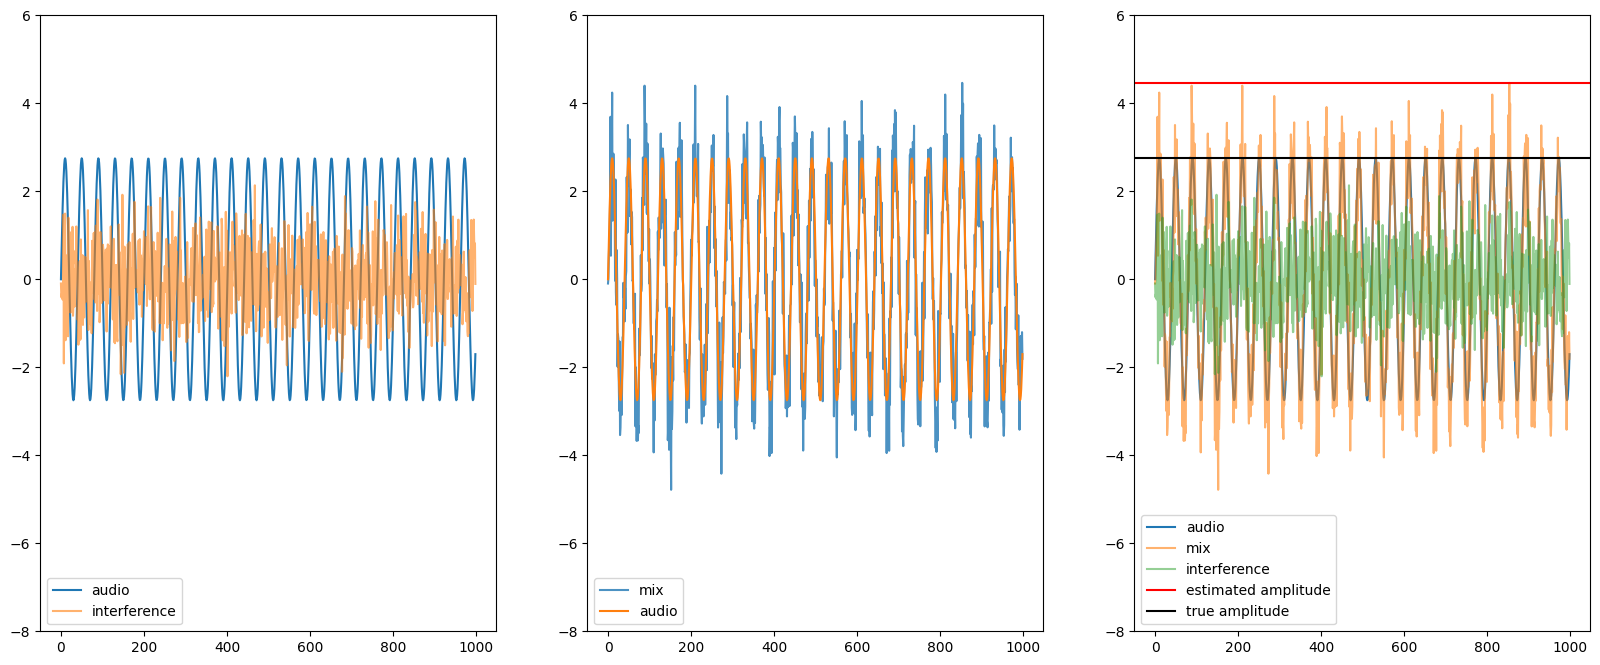

In [4]:
freq = 550
(t,audio1) = generate_sinusoid(amp = 2.75, freq=freq, dur=3)
print('Peak amplitude = %2.2f ' % peak_amplitude(audio1))
(t,audio2) = generate_sinusoid(amp = 0.5, freq=freq, dur=3)
print('Peak amplitude = %2.2f ' % peak_amplitude(audio2))

noise = np.random.normal(0, 0.75, len(audio1))
mix = audio1 + noise

def mix_plot(audio, interference, mix, amplitude_function):
  plt.rcParams["figure.figsize"] = (20,8)
  fig, (ax1, ax2, ax3) = plt.subplots(1,3)
  ax1.set_ylim((-8, 6))
  ax1.plot(audio, label='audio')
  ax1.plot(interference, label = 'interference', alpha=0.6)
  ax1.legend(loc='lower left')

  ax2.set_ylim((-8,6))
  ax2.plot(mix, label = 'mix', alpha=0.8)
  ax2.plot(audio, label='audio')
  ax2.legend(loc='lower left')

  ax3.set_ylim((-8,6))
  ax3.plot(audio, label='audio')
  ax3.plot(mix, label = 'mix', alpha=0.6)
  ax3.plot(interference, alpha = 0.5, label='interference')
  ax3.axhline(y=amplitude_function(mix), color='r', linestyle='-', label='estimated amplitude')
  ax3.axhline(y=amplitude_function(audio), color='black', linestyle='-', label='true amplitude')
  ax3.legend(loc='lower left')

mix_plot(audio1[0:999], noise[0:999], mix[0:999], peak_amplitude)
print('Actual amplitude = %2.2f ' % peak_amplitude(audio1[0:999]))
print('Peak amplitude = %2.2f ' % peak_amplitude(mix[0:999]))

RMS amplitude = 2.75 
RMS amplitude = 2.96 


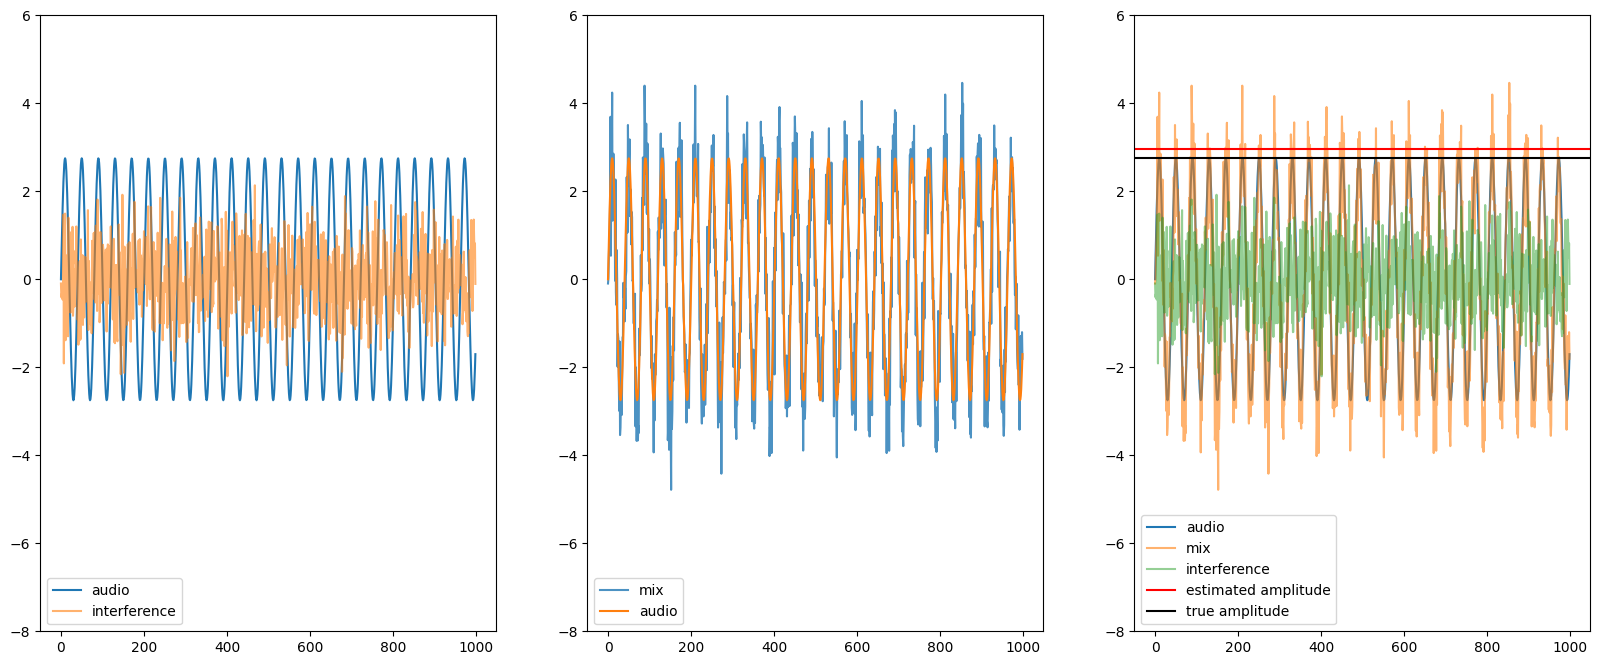

In [5]:
def rms_amplitude(data):
    rms_sum = np.sum(np.multiply(data,data))
    rms_sum /= len(data)
    return np.sqrt(rms_sum) * np.sqrt(2.0)

print('RMS amplitude = %2.2f ' % rms_amplitude(audio1[0:999]))
print('RMS amplitude = %2.2f ' % rms_amplitude(mix[0:999]))

mix_plot(audio1[0:999], noise[0:999], mix[0:999], rms_amplitude)


## Correlation-based amplitude estimation (dot-product)

To deal more robustly with interference we will have to make some additional assumption to perform amplitude estimation of sinusoidal signal. The additional assumption will be that we know the frequency and phase of the sinusoidal signal that we are trying to estimate the amplitude. Even though this scenario is more restrictive the knowledge of the frequency and phase of what we are looking forward will help us develop a very robust amplitude estimation method.

By knowing the frequency we can reliably estimate the amplitude in much more challenging conditions. To do so we will be utilizing the dot product between two signals/arrays which is defined as:

$$
<x,y> = \sum_{n=0}^{N-1} x[n] * y[n]
$$

Knowing the frequency $\omega$ we are trying to estimate the amplitude for we can create a "probe" sinusoid of the same frequency $\omega$ and unit amplitude. Taking the dot product of our input signal which has other interferring sounds with the "probe" sinusoid will allow us to robustly estimate the amplitude of that sinusoid. **Important note:** this works only if both the sinusoids that is burried with other sounds and the "probe" sinusoids have the same phase. Later on we will use the term "basis" for this "probe" sinusoid of unit amplitude and matching phase.

Correlation is way to describe the similarity between two signal shapes. If the two signals considered are standarized (i.e their mean is set ot 0 and their standard devition to 1) their correlation is equal to their dot-produce.


Dot amplitude = 2.75 
Dot amplitude = 2.76 


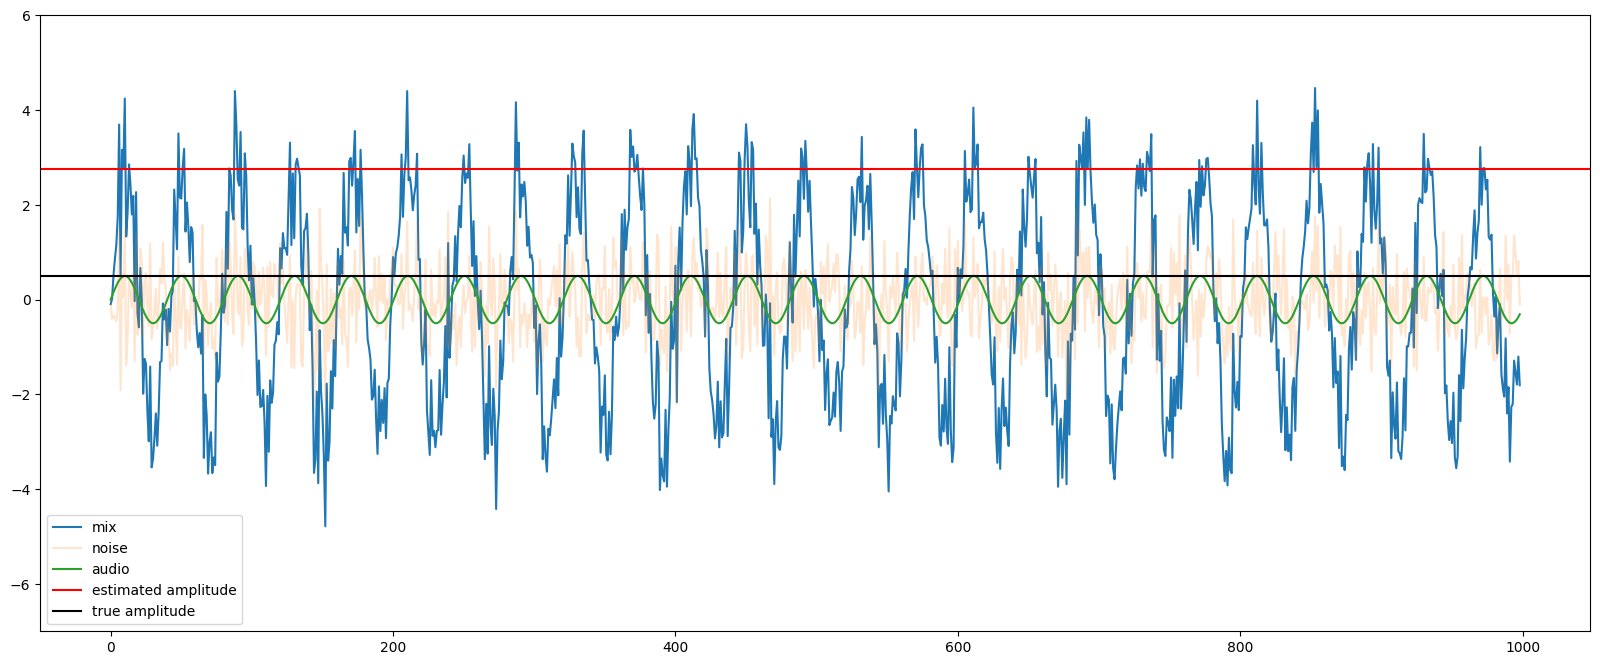

In [6]:
def dot_amplitude_freq(audio, freq):
    dur = audio.shape[0] / srate
    # create the probe/basis sinusoid for the right frequency
    (t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)
    dot_product = np.dot(audio, basis)
    return 2 * (dot_product / len(audio))

freq = 550
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(audio1, freq))
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(mix, freq))


plt.figure()
plt.ylim((-7, 6))
plt.plot(mix[0:999], label = 'mix')
plt.plot(noise[0:999], alpha = 0.2, label='noise')
plt.plot(audio2[0:999], label='audio')

plt.axhline(y=dot_amplitude_freq(mix[0:999], freq), color='r', linestyle='-', label='estimated amplitude')
plt.axhline(y=dot_amplitude_freq(audio2[0:999], freq), color='black', linestyle='-', label='true amplitude')
plt.legend(loc='lower left')


# PART 3 Dealing with Phase and Time

So far we have assumed that the unit amplitude basis (or probe) sinusoidal signal that we use for the dot-product amplitude estimation is in phase with the sinusoidal signal for which we are trying to estimate the amplitude. Let's see what can happen if that assumption does not hold i.e the basis and the original sinusoidal signal have the same frequency but different phases.
As you can see below it is clear that our correlation (dot-product) based amplitude estimation does not work when the phases of the basis (probe) and the signal in the input mixture are not aligned.


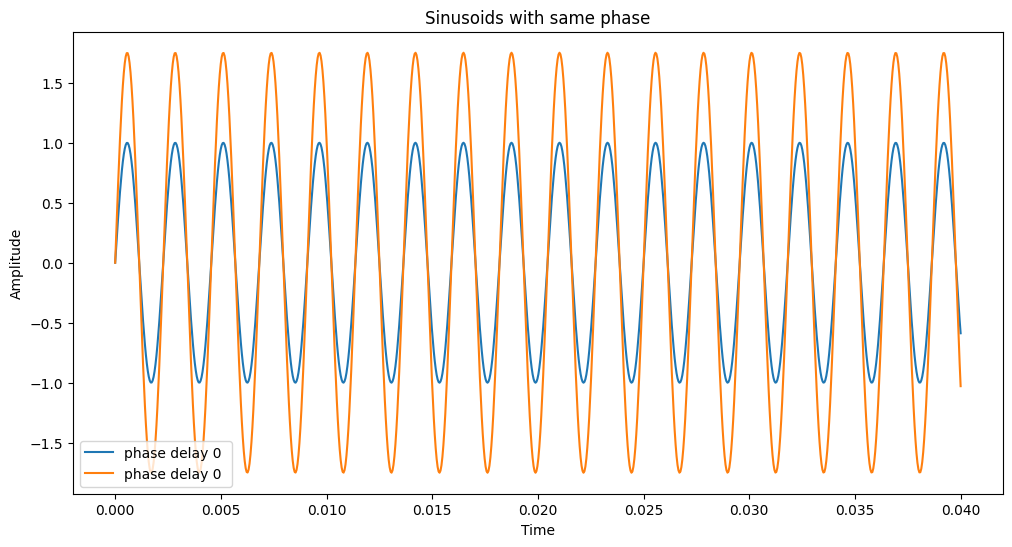

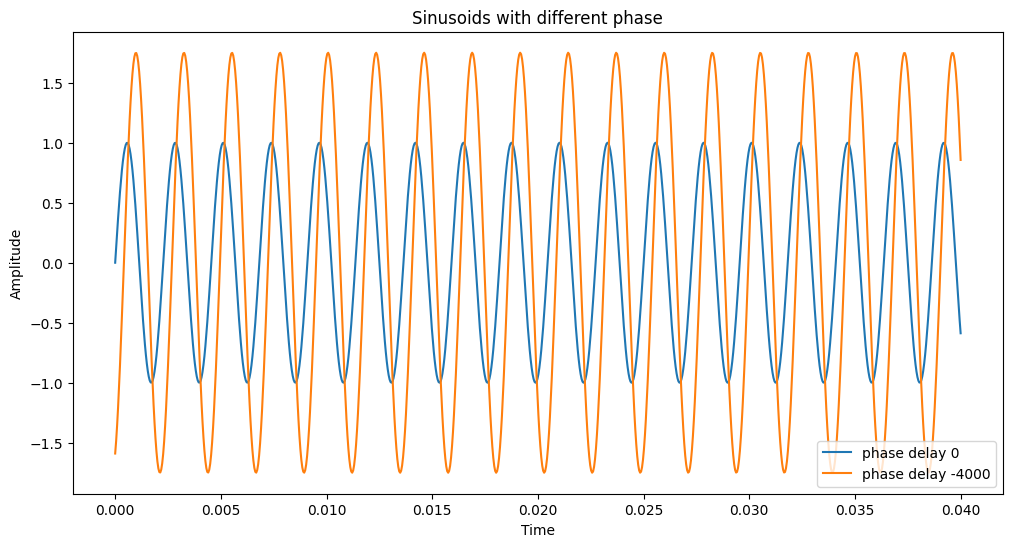

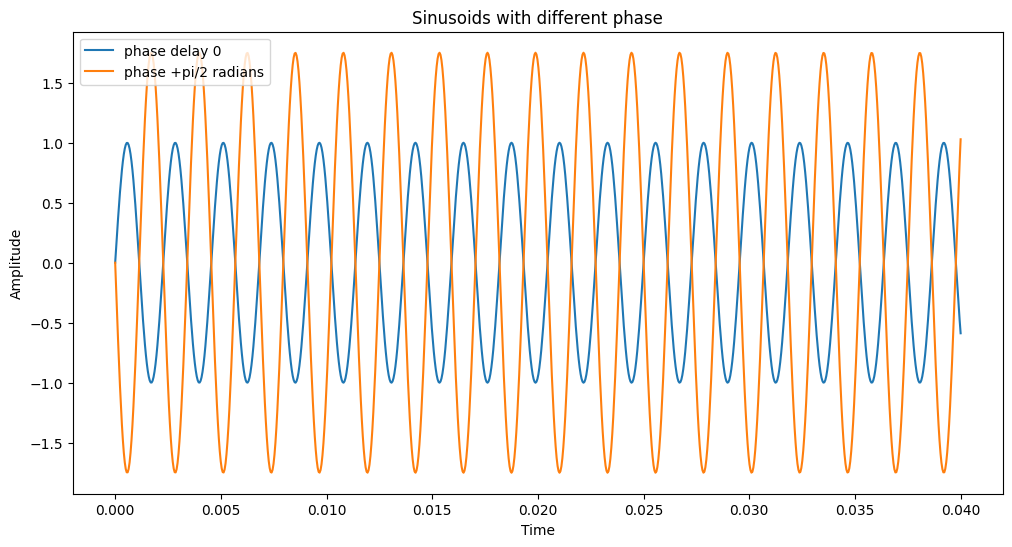

In [7]:

(t,probe) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.0, phase = 0.0)
(t,data1) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.75, phase = 0.0)
(t,data2) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.75, phase = -4000 * (2 * np.pi / srate))
(t,data3) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.75, phase = np.pi)

fig = plt.figure(figsize=(12,6))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with same phase')
plt.plot(t, probe, t, data1)
plt.legend(['phase delay 0 ', 'phase delay 0'])
plt.show()

fig = plt.figure(figsize=(12,6))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with different phase')
plt.plot(t, probe, t, data2)
plt.legend(['phase delay 0 ', 'phase delay -4000'])
plt.show()

fig = plt.figure(figsize=(12,6))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with different phase')
plt.plot(t, probe, t, data3)
plt.legend(['phase delay 0 ', 'phase +pi/2 radians'])
plt.show()


As you can see if the sinusoid for which we are trying to estimate the amplitude does not have the same phase as the basis unit amplitude probe sinusoid then the amplitude estimation does not work. Visually you can understand this by looking at the plots and realizing that only when the two sinusoids are aligned in terms of phase they correlate appropriately to perform the amplitude estimation. Let's see if that's the case. When the probe is not aligned in terms of phase our amplitude estimation does not work any more.


In [8]:
print(dot_amplitude_freq(data1, 440.0))
print(dot_amplitude_freq(data2, 440.0))
print(dot_amplitude_freq(data3, 440.0))


1.7412241565660342
0.7216382461773138
-1.7412241565660342


So now we have a robust way of estimating the amplitude of a sinusoid of a given frequency but it requires phase alignment between the basis probe signal of the frequency we are looking for . One idea that actually does work is to try different phase shifts and select the one that provides the highest/best amplitude estimation. Once we find the "best" shift we can then adjust the basis with unit amplitude to align with the complex sound and thus get the right amplitude estimation. However, this approach comes with a high computational cost. The operation of sliding the inner-products by different shifts is called a **cross-correlation **and is costly to perform for many shifts. Later, for the case of sinusoids Using some math we will see we can avoid this tedious brute-force approach and perform reliable amplitude estimation using only two inner products. We define a slightly different versionj of correlation amplitude estimation in which we provide directly the probe signal as a second argument rather than a frequency and then create it in the body of the function as we did before.

For each possible shift we plot the estimated amplitude - as you can see in the plots below these plots have a clear maximum which is approximately at the shift in which the probe/basis waveform and the sinsoid for which we are trying to estimate the amplitude are aligned in time. Knowing the corresponding shift in samples (which is directly related to the phase of the sinusoid) will allow us to align in time the two signals and perform reliable amplitude estimation.


Estimated shift (samples) for audio1 (no shift)=  54
Estimated shift (samples) for audio2 (shifted by 2000)  =  2007
Estimated shift (samples) for audio3 (shift by -1000) =  -944


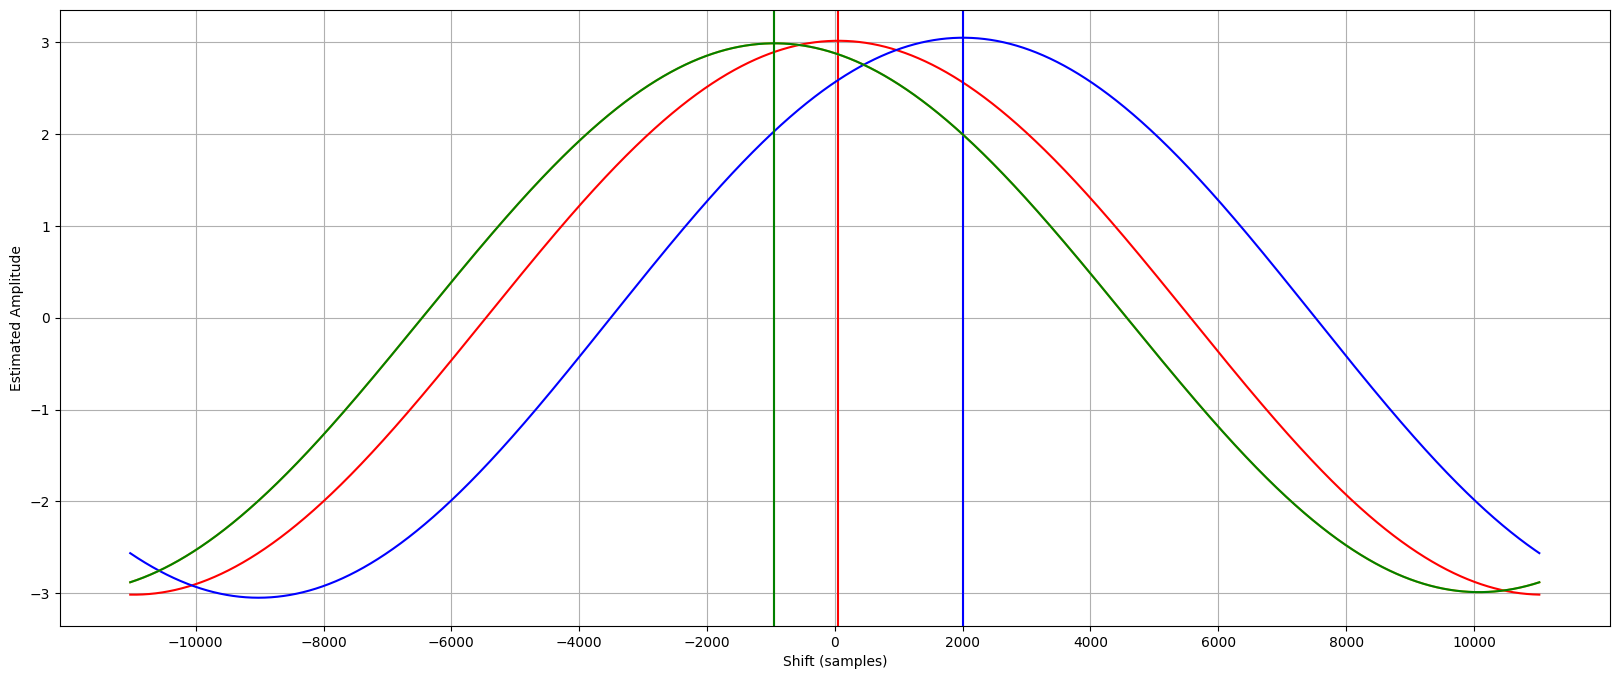

Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment audio2 = 2.56383810401335
Amplitude estimate for audio 2 with aligned probe = 3.0487819310917823


Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment data3 = 2.880459900728853
Amplitude estimate with alignment data3 = 2.9879543223837834


In [9]:
def dot_amplitude(audio, basis):
    dur = audio.shape[0] / srate
    dot_product = np.dot(audio, basis)
    return 2 * (dot_product / len(audio))


def plot_amp_phases(data1, srate, color):
    amplitude_estimates = np.zeros(srate)
    shifts = np.arange(-int(srate/2), int(srate/2))
    # calculate the amplitude_estimate for different integer shifts (delays)
    for k in shifts:
        (t, data2) = generate_sinusoid(freq=440, dur = 0.02, amp = 1.0, phase = k * (2 * np.pi / srate))
        amplitude_estimates[k+int(srate/2)] = dot_amplitude(data1,data2)
    plt.plot(shifts, amplitude_estimates, color=color)
    # return the location of the highest peak as an estimate of the appropriate shift
    plt.axvline(x=shifts[np.argmax(amplitude_estimates)], color=color, linestyle='-')
    plt.ylabel("Estimated Amplitude")
    plt.xlabel("Shift (samples)")

    return shifts[np.argmax(amplitude_estimates)]


srate = 22050

k = 0
(t,probe) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = 0)
(t,audio1) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 0)

shift_audio1 = plot_amp_phases(audio1, srate, 'red')
print('Estimated shift (samples) for audio1 (no shift)= ', shift_audio1)

(t,audio2) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 2000 * (2 * np.pi / srate))
shift_audio2 = plot_amp_phases(audio2, srate, 'blue')
print('Estimated shift (samples) for audio2 (shifted by 2000)  = ', shift_audio2)

(t,audio3) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = -1000 * (2 * np.pi / srate))
shift_audio3 = plot_amp_phases(audio3, srate, 'orange')
print('Estimated shift (samples) for audio3 (shift by -1000) = ', shift_audio3)
plot_amp_phases(audio3, srate, 'green')

plt.xticks(np.arange(-10000, 11000, 2000))
plt.grid()
plt.show()

print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment audio2 =', dot_amplitude(probe, audio2))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio2 * (2 * np.pi / srate))
print('Amplitude estimate for audio 2 with aligned probe =', dot_amplitude(probe_shifted, audio2))
print('\n')

print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment data3 =', dot_amplitude(probe, audio3))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio3 * (2 * np.pi / srate))
print('Amplitude estimate with alignment data3 =', dot_amplitude(probe_shifted, audio3))

Notice a couple of things about the code above. The resolution for the different shifts is one sample. We can imagine scenarios in which we will
need more accurate phases that would correspond to a fractional delay. Another observation is that we can either shift the basis/probe after estimating the shift or shift the signal - the result would be the same. Finally you can see that the shift estimation is not exactly accurate but it does give a reasonble approximation.

Doing the cross-products for every possible time shift is also computationally heavy and you notice the delay in computing the output of this cell. We can make things a bit faster by vectorizing the loops and computing less shifts at the expense of amplitude estimation accuracy.

Estimated shift for audio1 =  275
Estimated shift for audio2 =  2227
Estimated shift for audio3 =  -944


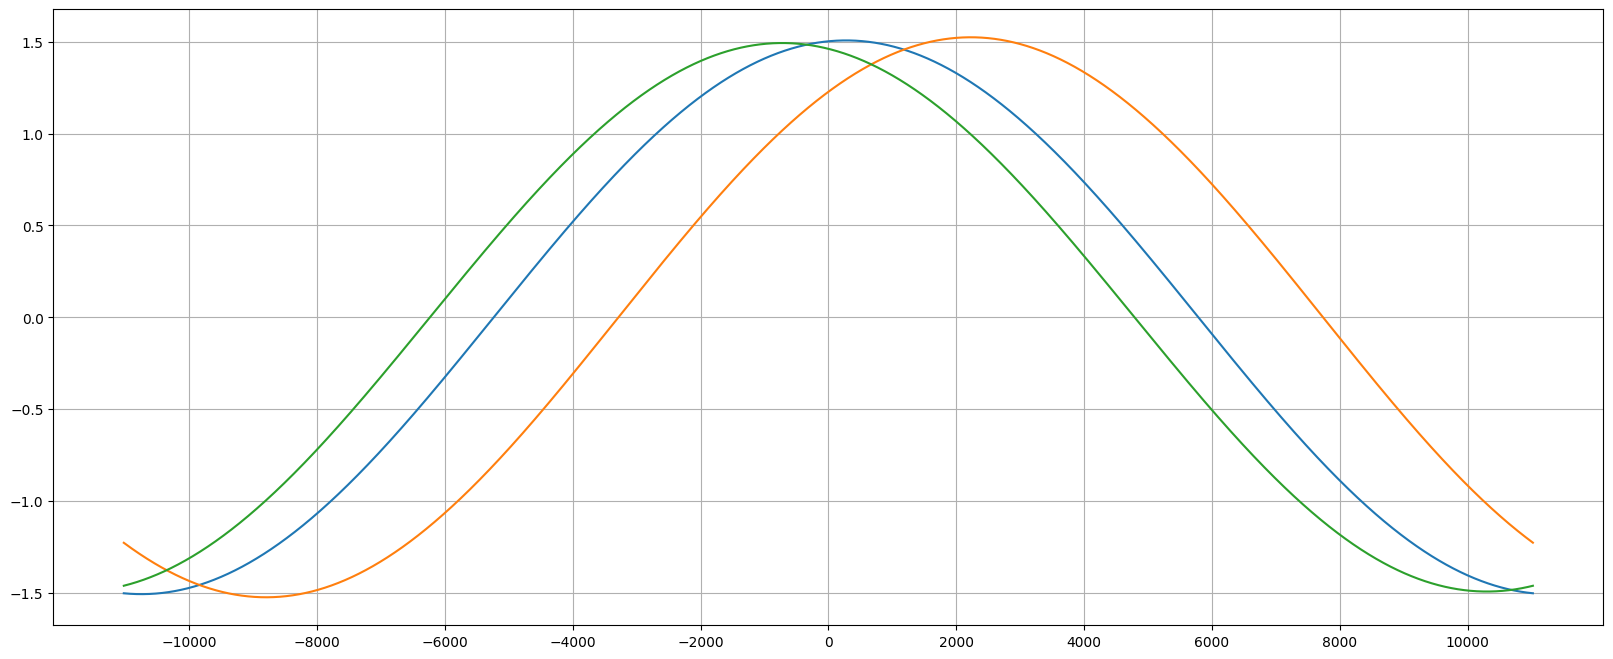

Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment audio2 = 2.56383810401335
Amplitude estimate for audio 2 with aligned probe = 3.042770757457799


Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment data3 = 2.880459900728853
Amplitude estimate with alignment data3 = 2.9879543223837834


In [11]:
def plot_amp_phases_vectorized(data1, srate, step_size):
    # 1. Define shifts and time array once
    shifts = np.arange(-int(srate / 2), int(srate / 2), step_size)
    t = np.linspace(0, len(data1)/srate, int(len(data1)), endpoint=False) # standard time array for 0.02s

    # 2. Calculate phase vector (shape: [num_shifts, 1])
    phases = (shifts * (2 * np.pi / srate))[:, np.newaxis]

    # 3. Create 2D array of sinusoids via broadcasting (shape: [num_shifts, num_samples])
    data2_matrix = np.sin(2 * np.pi * 440 * t + phases)

    # 4. Vectorize the amplitude estimation step
    # Example assuming amplitude_estimate is cross-correlation or dot product normalized:
    # amplitude_estimates = np.dot(data2_matrix, data1) / len(data1)
    # OR if using a custom vector-compatible amplitude function:
    amplitude_estimates = np.dot(data2_matrix, data1) / len(data1)
    plt.plot(shifts, amplitude_estimates)

    return shifts[np.argmax(amplitude_estimates)]


srate = 22050
k = 0
step_size = 4

(t,probe) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = 0)
(t,audio1) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 0)

shift_audio1 = plot_amp_phases_vectorized(audio1, srate, step_size)
print('Estimated shift for audio1 = ', shift_audio1)

(t,audio2) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 2000 * (2 * np.pi / srate))
shift_audio2 = plot_amp_phases_vectorized(audio2, srate, step_size)
print('Estimated shift for audio2 = ', shift_audio2)

(t,audio3) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = -1000 * (2 * np.pi / srate))
shift_data4 = plot_amp_phases_vectorized(audio3, srate, step_size)
print('Estimated shift for audio3 = ', shift_audio3)

plt.xticks(np.arange(-10000, 11000, 2000))
plt.grid()
plt.show()


print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment audio2 =', dot_amplitude(probe, audio2))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio2 * (2 * np.pi / srate))
print('Amplitude estimate for audio 2 with aligned probe =', dot_amplitude(probe_shifted, audio2))
print('\n')

print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment data3 =', dot_amplitude(probe, audio3))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio3 * (2 * np.pi / srate))
print('Amplitude estimate with alignment data3 =', dot_amplitude(probe_shifted, audio3))

Now we can package this approach without the plots into a new function for estimating the amplitude using cross-correlation that requires knowledge of the particular frequency we are looking for but does **NOT** require time (phase) alignment.

In [12]:
def cross_correlation_amplitude(data, freq, srate, step_size):
    # 1. Define shifts and time array once
    shifts = np.arange(-int(srate / 2), int(srate / 2), step_size)
    t = np.linspace(0, len(data)/srate, int(len(data)), endpoint=False) # standard time array

    # 2. Calculate phase vector (shape: [num_shifts, 1])
    phases = (shifts * (2 * np.pi / srate))[:, np.newaxis]

    # 3. Create 2D array of sinusoids via broadcasting (shape: [num_shifts, num_samples])
    data2_matrix = np.sin(2 * np.pi * freq * t + phases)

    # 4. Vectorize the amplitude estimation step
    # Example assuming amplitude_estimate is cross-correlation or dot product normalized:
    # amplitude_estimates = np.dot(data2_matrix, data1) / len(data1)
    # OR if using a custom vector-compatible amplitude function:
    amplitude_estimates = np.dot(data2_matrix, data) / len(data)
    return 2 * np.max(amplitude_estimates)

step_size = 4
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(probe, 440.0, srate, step_size))
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(audio1, 440.0, srate, step_size))
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(audio2, 440.0, srate, step_size))
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(audio3, 440.0, srate, step_size))

#

Cross-correlation amplitude estimate = 1.004673906367061
Cross-correlation amplitude estimate = 3.014021719101183
Cross-correlation amplitude estimate = 3.048210282133012
Cross-correlation amplitude estimate = 2.9856458755200217


## Sidenote Dichotic Pitch

Cross-correllation is a basic fundamental operation that consists of two steps delaying by different amount one signal in relation to another and then multiplying them together. There is clear evidence that forms of this delay and multiply/sum operation are taking place in our brain. For example dichotic pitch is a phenomenon where we can create a stimulus consisting of a left ear signal that is pure noise and a right ear signal that is pure noise delayed relative to the left ear. When these signals are heard individually you only hear noise. However, when they are played together with headphones one hears a distinct pitch with frequency related to the delay. This interesting phenomenon provides evidence that there is cross-processing of signals between the left and right ear and that pitch perception is affected by the delay and is based on some form of cross-correlation (delay and sum/multiply) processing. Of course having neural circuits this cross-correlation is not as clean mathematically as what we are describing but similar in nature.

**Exercise for the reader** Read about dichotic pitch, write some code to create the stimulus and see if you can hear the faint pitch.


## Does cross-correlation amplitude estimation work for a different periodic signal than sinusoids ?

The same cross-correlation approach to amplitude estimation can be performed using families with different wave-form shapes than sinusoids. For example we can do dot-product amplitude estimation using triangle waves or even using arbitrary waveforms. The process is the same with some caveats. Notice below that there is a different factor (3) in the triangle dot product estimation.
This factor can be generalized to be the mean of the squarred signal.

Having a different basis function can be useful if we are intereted in signals that are non-linear or non-stationary. This is related to what is called **matched filtering** in Digital Signal Processing.

In [13]:
def create_triangle(freq=440, amp=1.0, dur=1.0, srate=44100):
# Generates a triangular wave signa
  t = np.arange(0,dur,1.0/srate)
  output = np.zeros_like(t)
  for n in range(1,12,2):
    sign = (-1) ** ((n-1)/2)
    sinusoid = sign * (1.0/(n**2)) * np.sin(2 * np.pi * n*freq * t)
    output += sinusoid
  return (t, amp * (8/(np.pi**2)) * output)

(t, audio) = generate_sinusoid(freq = 440, amp = 0.75, dur=1, srate=srate)
(t, probe) = generate_sinusoid(freq = 440, amp = 1.0, dur =1, srate=srate)

print('Dot amplitude = %2.2f ' % dot_amplitude(audio, probe))
ipd.Audio(audio, rate=srate)

def dot_amplitude_triangle(data1, data2):
    dot_product = np.dot(data1, data2)
    return 3 * (dot_product / len(data1))

(t, audiot) = create_triangle(freq = 440, amp = 0.75, dur=1, srate=srate)
(t, probet) = create_triangle(freq = 440, amp = 1.0, dur =1, srate=srate)
print('Dot amplitude = %2.2f ' % dot_amplitude_triangle(audiot, probet))

def dot_amplitude(data1, data2):
    dot_product = np.dot(data1, data2)
    k = np.mean(data2 ** 2)
    return (dot_product / len(data1) / k)

(t, audiot) = create_triangle(freq = 440, amp = 0.75, dur=1, srate=srate)
(t, probet) = create_triangle(freq = 440, amp = 1.0, dur =1, srate=srate)
print('Dot amplitude = %2.2f ' % dot_amplitude(audiot, probet))


Dot amplitude = 0.75 
Dot amplitude = 0.75 
Dot amplitude = 0.75 


# Dealing with time

So far we have discussed amplitude estimation using the dot-product/cross-correlation approach of looking for a specific frequency in our mixture of sounds signal. What if we have as input a signal that changes over time (for example the simple melody played by sinusoidal oscillators) ? The typical way to deal with this is what is called short-time processing. Basically we process the audio signal in shorter chunks of samples (typically called windows or frames). Each chunk must be long enough to contain at least one cycle of our signal of interest but short enough that the frequency we are interested in remains present during the chunk. For now the chunks that will be processed will not be overlapping but later we will see how overlapping can also be used in short-time processing.

Let's say that we process the sound in chunks of 1024 samples. For each
chunk we can estimate the amplitude of a particular frequency of interest and we can use multiple probes/basis functions if we are interested in more than one frequency. For the toy example below we will use three notes or pitches playing the simple melody. We can then estimate through analysis the amplitude "envelope" of each of these notes. This can be considered as a very basic and simplified form of music transcription, the process of converting audio and discrete music symbols that provide instructions of how the music can be performed.





In [14]:
import scipy.signal as signal

# frequencies of three notes (C, D, E)
c_freq = 523.0
d_freq = 587.0
e_freq = 659.0

# generate sine signals corresponding to each note
(t,c_data) = generate_sinusoid(freq = c_freq, dur = 0.5, amp = 0.5, srate = srate)
(t,d_data) = generate_sinusoid(freq = d_freq, dur = 0.5, amp = 0.5)
(t,e_data) = generate_sinusoid(freq = e_freq, dur = 0.5, amp = 0.5)

# form a simple melody by concateneting the signal arrays for each note
melody = np.hstack([c_data, d_data, e_data, c_data, c_data, d_data, e_data, c_data])
ipd.Audio(melody,rate=srate, normalize=False)



We will now perform short-time process to our melody and extract 3 amplitude envelopes. Notice that we can easily reconstruct the original audio from
the short chunks that we cut it into. Also notice that the step size for computing the shifts for the cross-correlation is coarse (64 samples). The window size of 1024 samples results in 87 amplitude estimates for each of the three probes. This is so that the computation does not take too long but also means that are shift estimates and the associated amplitudes will not be as accurate. On my laptop this takes computation takes about 2 seconds.


In [15]:
%%time

# This will take a few seconds
hopSize = 1024
winSize = 1024
offsets = np.arange(0, len(melody), hopSize)

output = np.zeros(len(melody))
c_amplitudes = []
d_amplitudes = []
e_amplitudes = []
print("Length of offsets:", len(offsets))

# Note that we use a big step size to consider less phase shift - otherwise
# this process will take too long
step_size = 64
for (m,o) in enumerate(offsets):
    frame = melody[o:o+winSize]
    if len(frame) < winSize:
          break  # Ignore incomplete segment
    c_amplitudes.append(cross_correlation_amplitude(frame, c_freq, srate, step_size))
    d_amplitudes.append(cross_correlation_amplitude(frame, d_freq, srate, step_size))
    e_amplitudes.append(cross_correlation_amplitude(frame, e_freq, srate, step_size))
    output[o:o+winSize] += frame
ipd.Audio(output, rate=srate)


Length of offsets: 87
CPU times: user 1.8 s, sys: 3.1 ms, total: 1.8 s
Wall time: 1.8 s


Let's look at the resulting estimated amplitude envelopes for our meody. You can clearly see how the notes change and repeat.




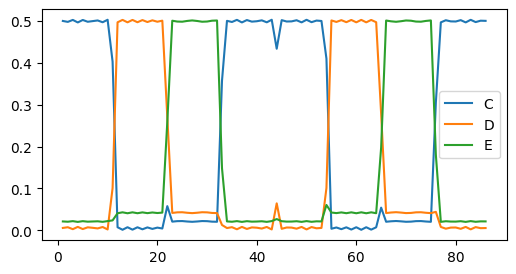

In [16]:
t = np.arange(1, len(c_amplitudes)+1)
fig = plt.figure(figsize=(6,3))
plt.plot(t, c_amplitudes)
plt.plot(t, d_amplitudes)
plt.plot(t, e_amplitudes)
plt.legend(['C', 'D', 'E'])
plt.show()


# Dealing with mismatch between probe frequency and actual frequency

Let's take a look at what happens if there is a mismatch between the probe frequency and the actual frequency of the signal. As you can see very close frequencies can get a reasonable amplitude estimate but the accuracy of this estimation drops quickly as we move away from the basis/probe frequency. The top plot shows a more narrow range of mismatched frequencies and the bottom plot zooms out to a more broad range of mismatched frequencies. So we can use correlation with a probe/basis function as a method for amplitude estimation even when we don't know exactly what frequency we are looking for but the target frequency needs to be close to the probe frequency. The details of how close and what is the effect on estimation depend on the sampling rate and are beyond the scope of this exposition.

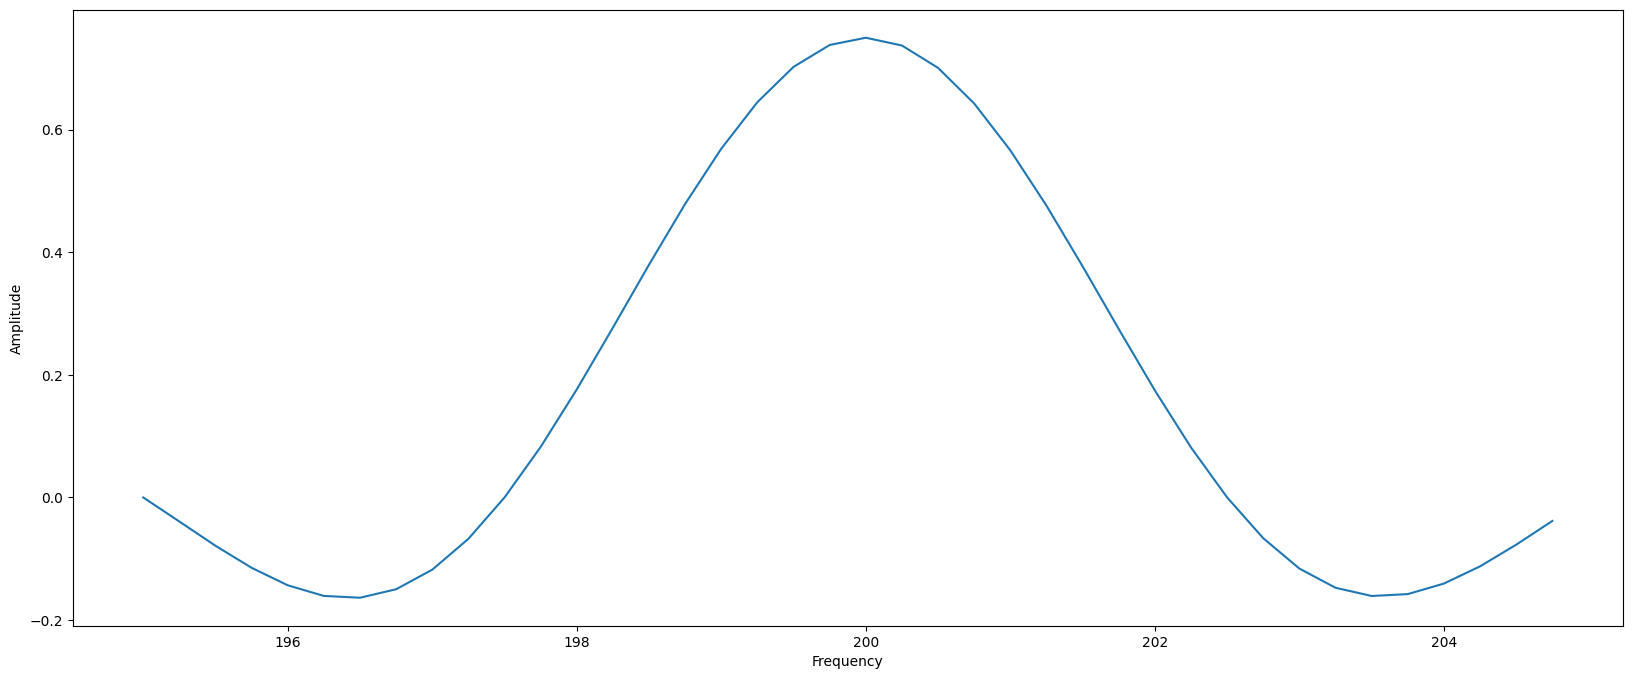

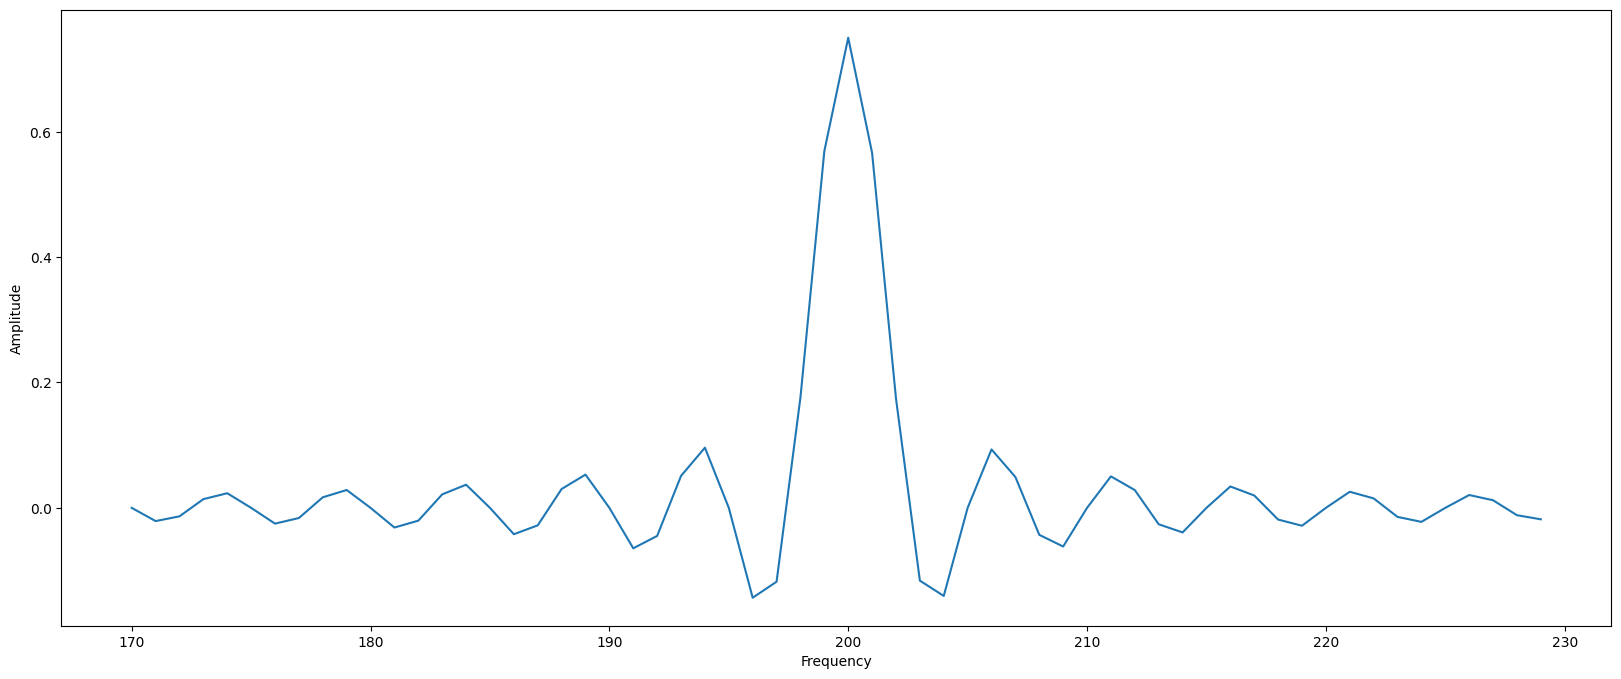

In [17]:
def dot_amplitude_sinusoid(data1, data2):
    dot_product = np.dot(data1, data2)
    return 2 * (dot_product / len(data1))

est_amplitudes = []

freq_range = np.arange(195, 205, 0.25 )
for f in freq_range:
  (t, audio) = generate_sinusoid(freq = f, amp = 0.75, dur=0.2, srate=srate)
  (t, probe) = generate_sinusoid(freq = 200, amp = 1.0, dur =0.2, srate=srate)
  est_amp = dot_amplitude(audio, probe)
  est_amplitudes.append(est_amp)
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.plot(freq_range, est_amplitudes)
plt.show()

est_amplitudes = []
freq_range = np.arange(170, 230, 1 )
for f in freq_range:
  (t, audio) = generate_sinusoid(freq = f, amp = 0.75, dur=0.2, srate=srate)
  (t, probe) = generate_sinusoid(freq = 200, amp = 1.0, dur =0.2, srate=srate)
  est_amp = dot_amplitude(audio, probe)
  est_amplitudes.append(est_amp)

plt.plot(freq_range, est_amplitudes)
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()


## Estimating phase using just two sinusoidal probes

So far everything we have described has used very basic math - essentially multiplications, additions, and sample shifts as well as the ability to calculate samples of a sine function. We will now see that using some mathematics we can avoid the computationally heavy cross-correlation approach of having to shift the probe for many possible shifts to achieve time alignment and get away with just computing two dot products between a pair of probes.

There is a simpler approach to estimating both the amplitude and the phase of a sinusoidal signal of known frequency. This approach will allow us estimate an arbitrary phase without having to try many possible shfits but simply calculating the dot products with two probe/basis signals.

It is based on the following identity:
\begin{equation} a \sin(x) + b \cos(x) = R \sin (x + \theta)
\end{equation}
where
$ R = \sqrt{(a^2 + b^2)} \;\; \text{and} \;\; \theta = \tan^{-1} \frac{b}{a} $

So basically we can represent a sinusoidal signal of a particular amplitude and phase as a weighted sum (with appropriate weights $ a \;\; \text{and}\;\; b$ of a sine signal and a cosine signal). So to estimate the amplitude and phase of a sinusoid of known frequency we can take the inner product with a pair of sine and cosine probe/basis signals of the same frequncy. Let's see how this would work. We will see later that these pairs of sines and cosine signals are what are called basis functions of the Discrete Fourier Transform (DFT).

Original amplitude  = 3.00
Original phase = 0.28
Estimated Magnitude = 3.00
Estimated Phase = 0.29


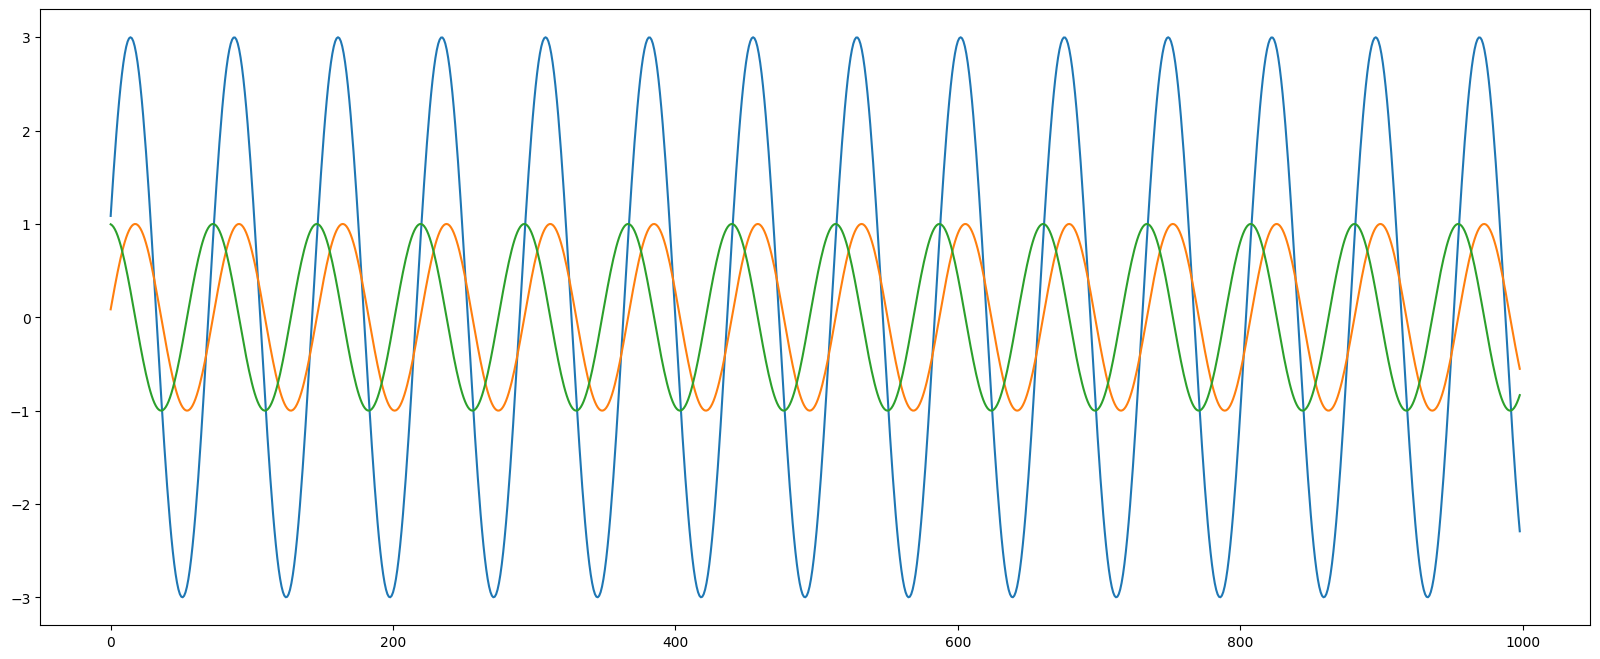

In [18]:
def dot_amplitude(data1, data2):
    dot_product = np.dot(data1, data2)
    return 2 * (dot_product / len(data1))

srate = 22050
amplitude = 3.0
k = 1000
phase = k * (2 * np.pi / srate)
print('Original amplitude  = %2.2f' % amplitude)
print('Original phase = %2.2f' % phase)

(t,data) = generate_sinusoid(freq=300, dur = 0.5, amp =amplitude, phase = phase)
plt.plot(data[1:1000])
(t,basis_sin) = generate_sinusoid(freq=300, dur=0.5, amp = 1)
(t,basis_cos) = generate_sinusoid(freq=300, dur=0.5, amp = 1, phase = np.pi/2)
plt.plot(basis_sin[1:1000])
plt.plot(basis_cos[1:1000])

# we take to dot-products of our input signal - one with the sin basis function
# and one with the cos basis function. Together these two estimates a and b are used to
# estimate both the amplitude/magnitude and the phase

a = dot_amplitude(data, basis_sin)
b = dot_amplitude(data, basis_cos)

estimated_phase = np.arctan(b/a)
estimated_magnitude = np.sqrt(a*a+b*b)

print('Estimated Magnitude = %2.2f' % estimated_magnitude)
print('Estimated Phase = %2.2f' % estimated_phase)

NameError: name 'data0' is not defined

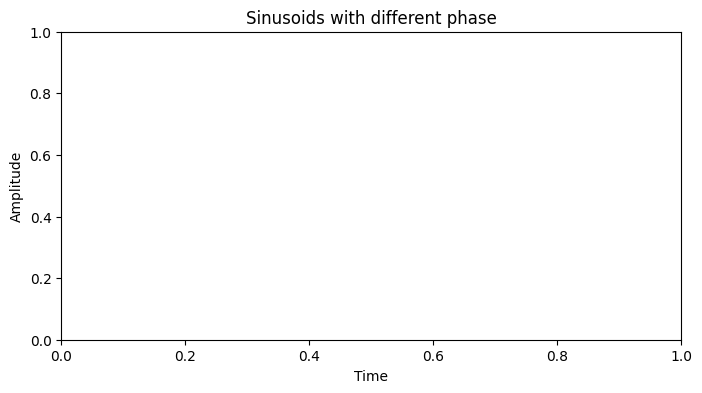

In [19]:
srate = 22050

(t,basis_cos) = generate_sinusoid(freq = 440, dur = 0.02,amp = 1.0, phase = np.pi/2)
(t,basis_sin) = generate_sinusoid(freq = 440, dur = 0.02,amp = 1.0, phase = 0)

fig = plt.figure(figsize=(8,4))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with different phase')
plt.plot(t[0:100], data0[0:100], t[0:100], data1[0:100])
plt.legend(['cosine basis', 'sine basis'])
plt.show()

imaginary = dot_amplitude(basis_sin, audio1)
real = dot_amplitude(basis_cos, audio1)


a = real
b = imaginary
print('a =', a)
print('b =', b)
print('Amp =', np.sqrt(a*a+b*b))
print('Angle = ', np.arctan2(b,a))
print('\n')

a = dot_amplitude(data1, audio2)
b = dot_amplitude(data0, audio2)
print('a =', a)
print('b =', b)
print('Amp =', np.sqrt(a*a+b*b))
print('Angle = ', np.arctan2(b,a))

print('\n')

a = dot_amplitude(data1, audio3)
b = dot_amplitude(data0, audio3)
print('a =', a)
print('b =', b)
print('Amp =', np.sqrt(a*a+b*b))
print('Angle = ', np.arctan2(b,a))

print('\n')



Intuitively what is happening is that when the target signal has phase that shifts is closer to the sine probe the sine estimate gets higher and when the target signal has a phase that shifts closer to the cosine probe the cosine estimate gets higher. By combining them appropriately we get **both** the amplitude and the phase and only need to compute two dot-products of our arrays. Note that this computational efficiency is only possible because we are using sinusoids and can get away with using a pair of probes. For arbitrary probe waveforms we would have to resort to the computationally expensive cross-correlation.

The space of sinusoids of the same frequency is closed under addition i.e when we add two sinusoids of the same frequency even if their amplitudes and phases are different the result is also a sinusoids of the same frequency. This is an important observation that we will return to.

So let's recap. If we are looking for the amplitude of a sinusoidal signal that is part of a complex signal and we know it's frequency we can take use inner-products of array corresponding to the complex signal that contains our "burried" sinusoid with two basis arrays (or probes) one containing a sampled sine signal of the known frequency and one containing a sampled cosine signal of the known frequency.
The resulting estimates which we call "real" and "imaginary" can be combined to return an estimate of the mangitude of the sinusoid as well as an estimate of the phase. Each of these sinusoids can be considered a "probe" or "basis" and is a building block that can take as input a complex input signal consisting of multiple sinusoidal signals and potentially other interferring sounds and estimate reliably the amplitude and the phase of of a sinusoid with a particular frequency of interest.

**Exercise for the reader** Check that the short-time amplitude estimation of the melody that was done above using cross-correlation amplitude estimation will still work when using a pair of probes. Compare the running time to estimate the amplitude envelope of each pitch using the two approaches. Resynthesize the melody from the estimate amplitude envelopes.


